# <u> Loading All Packages </u>

In [131]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import re
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, confusion_matrix, roc_curve, auc)
from sklearn.metrics import classification_report
import seaborn as sns
import os
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import random
import numpy as np
import torch
import subprocess

In [132]:
# Set seeds
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [133]:

subprocess.run(['nvidia-smi'])
# set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Wed May  6 14:54:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     Off |   00000000:3F:00.0 Off |                  N/A |
| 41%   57C    P2             64W /  250W |    5159MiB /  11264MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [134]:
# Check if GPU is available
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")

# List all GPUs
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# Current GPU
print(f"Current GPU: {torch.cuda.current_device()}")
print(f"Current GPU name: {torch.cuda.get_device_name()}")

# GPU memory
print(f"\nGPU Memory:")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.total_memory / 1e9:.2f} GB total")

GPU Available: True
Number of GPUs: 2
GPU 0: NVIDIA GeForce RTX 2080 Ti
GPU 1: NVIDIA GeForce RTX 2080 Ti
Current GPU: 0
Current GPU name: NVIDIA GeForce RTX 2080 Ti

GPU Memory:
  GPU 0: 11.35 GB total
  GPU 1: 11.35 GB total


# <u> Prepping Data Dimensions </u>



In [135]:
BODY_PART_MAP = {
    'ELBOW':    0,
    'FINGER':   1,
    'FOREARM':  2,
    'HAND':     3,
    'HUMERUS':  4,
    'SHOULDER': 5,
    'WRIST':    6,
}
BODY_PARTS   = list(BODY_PART_MAP.keys())
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 4
NORM_MEAN    = [0.485, 0.456, 0.406]
NORM_STD     = [0.229, 0.224, 0.225]

# <u> Local Path to Data </u>



In [136]:
# Get the current working directory (where the notebook is)
DRIVE_ROOT = os.getcwd()

# Set image directories
SHORTCUT_ROOT = Path(DRIVE_ROOT)
TRAIN_IMG_DIR = SHORTCUT_ROOT / 'train'
VALID_IMG_DIR = SHORTCUT_ROOT / 'valid'
FRACATLAS_IMG_DIR = SHORTCUT_ROOT / 'fracatlas_images'

# Verify directories exist
print(f"Working directory: {DRIVE_ROOT}")
print(f"Train directory exists: {TRAIN_IMG_DIR.exists()}")
print(f"Valid directory exists: {VALID_IMG_DIR.exists()}")
print(f"FracAtlas directory exists: {FRACATLAS_IMG_DIR.exists()}")

# Path resolution function (same as before)
def get_abs_path(image_path_str: str, split: str = 'train') -> Path:
    rel = re.sub(r'^.*?(?:train|valid)/', '', image_path_str)
    return (TRAIN_IMG_DIR if split == 'train' else VALID_IMG_DIR) / rel

Working directory: /sfs/gpfs/tardis/home/kyq5rs/Documents/MSDS/DS6050_project
Train directory exists: True
Valid directory exists: True
FracAtlas directory exists: True


# <u> Data Loaders </u>



In [137]:
def _add_study_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns to a study-level DataFrame (in-place, returns df)."""
    df['image'] = (
        df['image']
        .astype(str)
        .str.replace(r'^MURA-v1\.1/', '', regex=True)
        .str.rstrip('/')
        .str.strip()
    )
    df['patient_id']        = df['image'].str.extract(r'(patient\d+)')[0]
    df['body_part']         = df['image'].str.extract(r'XR_(\w+)/')[0].str.upper()
    df['body_part_encoded'] = df['body_part'].map(BODY_PART_MAP)
    df['inferred_label']    = df['image'].str.contains('positive').astype(int)
    df['study_id']          = df['image'].str.extract(r'(study\d+)')[0]
    return df


def _add_image_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns to an image-level DataFrame (in-place, returns df)."""
    df['image'] = (
        df['image']
        .astype(str)
        .str.strip()
    )
    df['patient_id']        = df['image'].str.extract(r'(patient\d+)')[0]
    df['body_part']         = df['image'].str.extract(r'XR_(\w+)/')[0].str.upper()
    df['body_part_encoded'] = df['body_part'].map(BODY_PART_MAP)
    df['abnormality_label'] = df['image'].str.contains('positive').astype(int)
    df['study_id']          = df['image'].str.extract(r'(study\d+)')[0]
    df['study_path'] = (
        df['image']
        .str.replace(r'/image\d+\.(png|jpg|jpeg)$', '', regex=True)
        .str.rstrip('/')
        .str.strip()
    )
    return df


def load_csvs(drive_root: str):
    """Load and preprocess all four CSVs. Returns (train_study_df, valid_study_df,
    train_img_df, valid_img_df)."""
    train_study = pd.read_csv(os.path.join(drive_root, 'train_labeled_studies.csv'))
    valid_study = pd.read_csv(os.path.join(drive_root, 'valid_labeled_studies.csv'))

    # Normalise column name if needed
    for df in (train_study, valid_study):
        if 'image_path' in df.columns:
            df.rename(columns={'image_path': 'image'}, inplace=True)

    train_study = _add_study_cols(train_study)
    valid_study = _add_study_cols(valid_study)

    train_img = pd.read_csv(
        os.path.join(drive_root, 'train_image_paths.csv'), header=None, names=['image']
    )
    valid_img = pd.read_csv(
        os.path.join(drive_root, 'valid_image_paths.csv'), header=None, names=['image']
    )
    train_img = _add_image_cols(train_img)
    valid_img = _add_image_cols(valid_img)

    return train_study, valid_study, train_img, valid_img


train_study_df, valid_study_df, train_img_df, valid_img_df = load_csvs(DRIVE_ROOT)

print(f"Train studies : {len(train_study_df):,} | Valid studies : {len(valid_study_df):,}")
print(f"Train images  : {len(train_img_df):,}  | Valid images  : {len(valid_img_df):,}")
print(f"Train patients: {train_study_df['patient_id'].nunique():,} | "
      f"Valid patients: {valid_study_df['patient_id'].nunique():,}")

# class weight calculation

pos_count = (train_study_df['inferred_label'] == 1).sum()
neg_count = (train_study_df['inferred_label'] == 0).sum()
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float).to(device)
print(f"Positive weight: {pos_weight.item():.4f}")


Train studies : 13,457 | Valid studies : 1,199
Train images  : 36,808  | Valid images  : 3,197
Train patients: 11,184 | Valid patients: 783
Positive weight: 1.5994


# <u> Data Transformers

In [138]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])


# <u> Strategies for Using Data </u>



In [139]:
# Strip MURA prefix and create all_img_df
train_img_df["study_path"] = train_img_df["study_path"].str.replace(r'^MURA-v1\.1/', '', regex=True)
valid_img_df["study_path"] = valid_img_df["study_path"].str.replace(r'^MURA-v1\.1/', '', regex=True)

all_img_df = pd.concat([train_img_df, valid_img_df], axis=0).reset_index(drop=True)
all_img_df["study_path"] = all_img_df["study_path"].str.replace(r'^MURA-v1\.1/', '', regex=True)

## Strategy 1 (each study independent + each image has own observation)

In [140]:
train_study_paths_clean = set(train_study_df["image"].astype(str))
valid_study_paths_clean = set(valid_study_df["image"].astype(str))
train_set1_df = all_img_df[all_img_df["study_path"].isin(train_study_paths_clean)].copy()
valid_set_df = all_img_df[all_img_df["study_path"].isin(valid_study_paths_clean)].copy()

##  Strategy 2 (only keep 1 study by patient + each image has own observation)

In [141]:
def keep_one_study_per_patient_positive(study_df):
    study_df = study_df.copy()
    study_df = study_df.sort_values(["patient_id", "inferred_label", "image"], ascending=[True, False, True])
    kept_rows = []
    for patient_id, group in study_df.groupby("patient_id"):
        if (group["inferred_label"] == 1).any():
            chosen = group[group["inferred_label"] == 1].iloc[0]
        else:
            chosen = group.iloc[0]
        kept_rows.append(chosen)
    kept_df = pd.DataFrame(kept_rows).reset_index(drop=True)
    return kept_df

train_studies_s2 = keep_one_study_per_patient_positive(train_study_df)
kept_study_paths_s2 = set(train_studies_s2["image"].astype(str))
train_set2_df = train_img_df[train_img_df["study_path"].isin(kept_study_paths_s2)].copy()

In [142]:
print(f"\nStrategy 1: {len(train_set1_df):,} train | {len(valid_set_df):,} valid")
print(f"Strategy 2: {len(train_set2_df):,} train | {len(valid_set_df):,} valid")


Strategy 1: 36,808 train | 3,197 valid
Strategy 2: 30,616 train | 3,197 valid


# <u> Data Loaders</u>

In [143]:
class MURADataset(Dataset):
    def __init__(self, df: pd.DataFrame, split: str = 'train', transform=None):
        self.df        = df.reset_index(drop=True)
        self.split     = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(get_abs_path(row['image'], self.split)).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color=0)  # blank fallback
        if self.transform:
            image = self.transform(image)
        label     = torch.tensor(int(row['abnormality_label']), dtype=torch.long)
        body_part = torch.tensor(int(row['body_part_encoded']), dtype=torch.long)
        return image, label, body_part

    def get_labels(self):
        return self.df['abnormality_label'].astype(int).tolist()


def make_sampler(dataset: MURADataset) -> WeightedRandomSampler:
    labels        = dataset.get_labels()
    class_counts  = Counter(labels)
    class_weights = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}
    sample_wts    = [class_weights[l] for l in labels]
    return WeightedRandomSampler(sample_wts, num_samples=len(sample_wts), replacement=True)


def make_dataloaders(train_df: pd.DataFrame, valid_df: pd.DataFrame,
                     batch_size: int = BATCH_SIZE, num_workers: int = NUM_WORKERS):
    train_ds = MURADataset(train_df, split='train', transform=train_transform)
    valid_ds = MURADataset(valid_df, split='valid', transform=val_transform)
    pin = torch.cuda.is_available()
    pw  = num_workers > 0
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=make_sampler(train_ds),
        num_workers=num_workers, pin_memory=pin, persistent_workers=pw,
    )
    val_loader = DataLoader(
        valid_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin, persistent_workers=pw,
    )
    return train_loader, val_loader
    
def make_dataloaders2(train_df: pd.DataFrame, valid_df: pd.DataFrame,
                     batch_size: int = BATCH_SIZE, num_workers: int = NUM_WORKERS):
    train_ds = MURADataset(train_df, split='train', transform=train_transform)
    valid_ds = MURADataset(valid_df, split='valid', transform=val_transform)
    
    # Check if CUDA is available for pin_memory
    pin = torch.cuda.is_available()
    
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=make_sampler(train_ds),
        num_workers=2,             # Lower this from 4 to 2
        pin_memory=pin, 
        persistent_workers=False,  # CHANGE THIS TO FALSE
    )
    val_loader = DataLoader(
        valid_ds, batch_size=batch_size, shuffle=False,
        num_workers=2,             # Lower this from 4 to 2
        pin_memory=pin, 
        persistent_workers=False,  # CHANGE THIS TO FALSE
    )
    return train_loader, val_loader


train_loader_s1, val_loader_s1 = make_dataloaders(train_set1_df, valid_set_df)
train_loader_s2, val_loader_s2 = make_dataloaders(train_set2_df, valid_set_df)



/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# <u> Generating the Models </u>
We are generating four models:
1. ResNet50, single classification (abnormality)
2. ResNet50, double classification (abnormality & body part)
3. ConvNeXT, single classification (abnormality)
4. ConvNeXT, double classification (abnormality & body part)

## **ResNet50, single classification (abnormality)**

In [144]:
class Single_ResNet(nn.Module): # single classification on abnormality
    def __init__(self):
        super().__init__()
        self.resnet_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.resnet_backbone.fc.in_features
        self.resnet_backbone.fc = nn.Identity() # replaces classificaiton head with empty layer
        self.abnormal_head = nn.Linear(in_features, 1) # 1 abnormality porbability

    def forward(self, x):
        features = self.resnet_backbone(x)
        abnormal_logits = self.abnormal_head(features).squeeze(1)
        return abnormal_logits

# initialize the resnet model, pretrained
single_resnet = Single_ResNet().to(device)

# freeze backbone of baseline pretrained model
for param1 in single_resnet.resnet_backbone.parameters():
    param1.requires_grad = False

# unfreeze last layer
for param2 in single_resnet.resnet_backbone.layer4.parameters():
    param2.requires_grad = True
# train the heads
for param4 in single_resnet.abnormal_head.parameters():
    param4.requires_grad = True

single_resnet_loss_fn = nn.BCEWithLogitsLoss()
single_resnet_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, single_resnet.parameters()),
    lr=1e-4
)

## Testing single resnet on 2 strategies

In [145]:
# ── MODEL 1a: Single ResNet Strategy 1 ──────────────────────────────────────

single_resnet_s1 = Single_ResNet().to(device)


for param in single_resnet_s1.resnet_backbone.parameters():
    param.requires_grad = False
for param in single_resnet_s1.resnet_backbone.layer4.parameters():
    param.requires_grad = True
for param in single_resnet_s1.abnormal_head.parameters():
    param.requires_grad = True

loss_fn_s1 = nn.BCEWithLogitsLoss()
optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, single_resnet_s1.parameters()),
    lr=1e-4
)

# ── MODEL 1b: Single ResNet Strategy 2 ──────────────────────────────────────
single_resnet_s2 = Single_ResNet().to(device)

loss_fn_s2 = nn.BCEWithLogitsLoss()
optimizer_s2 = optim.Adam(
    filter(lambda p: p.requires_grad, single_resnet_s2.parameters()),
    lr=1e-4
)

print("\n✓ Single ResNet for S1 and S2 initialized and ready for training")


✓ Single ResNet for S1 and S2 initialized and ready for training


## **ResNet50, double classification (abnormality & body part)**


In [146]:
class Multi_ResNet(nn.Module): # multi because it does two different classifications
    def __init__(self):
        super().__init__()
        self.resnet_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = self.resnet_backbone.fc.in_features
        self.resnet_backbone.fc = nn.Identity() # replaces classificaiton head with empty layer

        self.body_part_head = nn.Linear(in_features, 7) # 7 body part
        self.abnormal_head = nn.Linear(in_features, 1) # 1 abnormality porbability

    def forward(self, x):
        features = self.resnet_backbone(x)
        body_part_logits = self.body_part_head(features)
        abnormal_logits = self.abnormal_head(features).squeeze(1)
        return body_part_logits, abnormal_logits

# initialize the resnet model, pretrained
multi_resnet = Multi_ResNet().to(device)


# freeze backbone of baseline pretrained model
for param1 in multi_resnet.resnet_backbone.parameters():
    param1.requires_grad = False

# unfreeze last layer
for param2 in multi_resnet.resnet_backbone.layer4.parameters():
    param2.requires_grad = True
# train the heads
for param3 in multi_resnet.body_part_head.parameters():
    param3.requires_grad = True
for param4 in multi_resnet.abnormal_head.parameters():
    param4.requires_grad = True

multi_resnet_body_loss_fn = nn.CrossEntropyLoss()
multi_resnet_abnormal_loss_fn = nn.BCEWithLogitsLoss()
multi_resnet_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, multi_resnet.parameters()),
    lr=1e-4
)

## **ConvNeXT, single classification (abnormality)**

In [147]:
class Single_ConvNeXt(nn.Module):  # single classification on abnormality
    def __init__(self):
        super().__init__()
        self.convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.abnormal_head = nn.Linear(768, 1)
    
    def forward(self, x):
        x = self.convnext.features(x)
        x = self.convnext.avgpool(x)
        x = x.flatten(1)
        abnormal_logits = self.abnormal_head(x).squeeze(1)
        return abnormal_logits

single_convnext = Single_ConvNeXt().to(device)


# freeze backbone
for param in single_convnext.convnext.parameters():
    param.requires_grad = False
for param in single_convnext.convnext.features[7].parameters():
    param.requires_grad = True
# train the head
for param in single_convnext.abnormal_head.parameters():
    param.requires_grad = True

single_convnext_loss_fn = nn.BCEWithLogitsLoss()
single_convnext_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, single_convnext.parameters()),
    lr=1e-4
)

## **ConvNeXT, double classification (abnormality & body part)**

In [148]:
class Multi_ConvNeXt(nn.Module):
    def __init__(self, num_body_parts):
        super().__init__()
        self.convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.anatomy_head = nn.Linear(768, num_body_parts)
        self.abnormal_head = nn.Linear(768, 1)

    def forward(self, x):
        x = self.convnext.features(x)
        x = self.convnext.avgpool(x)
        x = x.flatten(1)
        anatomy_logits = self.anatomy_head(x)
        abnormal_logits = self.abnormal_head(x).squeeze(1)
        return anatomy_logits, abnormal_logits

num_body_parts = 7
# initialize the model
# ── MODEL: Multi ConvNeXt WITH augmentation ────────────────────────────────
multi_convnext = Multi_ConvNeXt(num_body_parts=7).to(device)



for param in multi_convnext.convnext.parameters():
    param.requires_grad = False
for param in multi_convnext.convnext.features[7].parameters():
    param.requires_grad = True
for param in multi_convnext.anatomy_head.parameters():
    param.requires_grad = True
for param in multi_convnext.abnormal_head.parameters():
    param.requires_grad = True

multi_convnext_body_loss_fn = nn.CrossEntropyLoss()
multi_convnext_abnormal_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
multi_convnext_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, multi_convnext.parameters()),
    lr=1e-4
)

# ── MODEL: Multi ConvNeXt WITHOUT augmentation ─────────────────────────────
multi_convnext_no_aug = Multi_ConvNeXt(num_body_parts=7).to(device)

for param in multi_convnext_no_aug.convnext.parameters():
    param.requires_grad = False
for param in multi_convnext_no_aug.convnext.features[7].parameters():
    param.requires_grad = True
for param in multi_convnext_no_aug.anatomy_head.parameters():
    param.requires_grad = True
for param in multi_convnext_no_aug.abnormal_head.parameters():
    param.requires_grad = True

multi_convnext_no_aug_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, multi_convnext_no_aug.parameters()),
    lr=1e-4
)


# <u> Training and Validating the Models </u>

In [149]:
# training loop for single models

def train_single(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    model_device = next(model.parameters()).device
    for imgs, labels, _ in loader:          
        imgs   = imgs.to(model_device)  
        labels = labels.float().to(model_device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
    

def validate_single(model, loader, loss_fn):
    model.eval()
    total_loss, all_probs, all_true = 0.0, [], []
    model_device = next(model.parameters()).device
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(model_device)
            labels = labels.float().to(model_device)
            logits = model(imgs)
            loss = loss_fn(logits, labels)
            total_loss += loss.item()
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_true.extend(labels.cpu().numpy())
    all_preds = (np.array(all_probs) >= 0.5).astype(int)
    all_true = np.array(all_true)
    return {
        'accuracy': accuracy_score(all_true, all_preds),
        'val_loss': total_loss / len(loader),
        'auc': roc_auc_score(all_true, all_probs),
        'sensitivity': recall_score(all_true, all_preds, zero_division=0),
        'ppv': precision_score(all_true, all_preds, zero_division=0),
        'f1': f1_score(all_true, all_preds, zero_division=0),
        'all_probs': all_probs,
        'all_true': all_true,
        'all_preds': all_preds,
    }

In [150]:
# train multi models
def train_multi(model, loader, optimizer, abnormal_loss_fn, body_loss_fn):
    model.train()
    total_loss = 0.0
    model_device = next(model.parameters()).device
    abnormal_loss_fn.pos_weight = abnormal_loss_fn.pos_weight.to(model_device)
    for imgs, labels, body_parts in loader:
        imgs       = imgs.to(model_device)
        labels     = labels.float().to(model_device)
        body_parts = body_parts.to(model_device)
        optimizer.zero_grad()
        body_logits, abnormal_logits = model(imgs)
        loss = abnormal_loss_fn(abnormal_logits, labels) + body_loss_fn(body_logits, body_parts)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate_multi(model, loader, abnormal_loss_fn, body_loss_fn):
    model.eval()
    total_loss, all_probs, all_true = 0.0, [], []
    body_preds, body_true = [], []
    model_device = next(model.parameters()).device
    with torch.no_grad():
        for imgs, labels, body_parts in loader:
            imgs = imgs.to(model_device)
            labels = labels.float().to(model_device)
            body_parts = body_parts.to(model_device)
            body_logits, abnormal_logits = model(imgs)
            loss = abnormal_loss_fn(abnormal_logits, labels) + body_loss_fn(body_logits, body_parts)
            total_loss += loss.item()
            all_probs.extend(torch.sigmoid(abnormal_logits).cpu().numpy())
            all_true.extend(labels.cpu().numpy())
            body_preds.extend(body_logits.argmax(dim=1).cpu().numpy())
            body_true.extend(body_parts.cpu().numpy())

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)
    all_preds = (all_probs >= 0.5).astype(int)
    body_true = np.array(body_true)
    body_preds = np.array(body_preds)

    return {
        'val_loss': total_loss / len(loader),
        'accuracy': accuracy_score(all_true, all_preds),
        'auc': roc_auc_score(all_true, all_probs),
        'sensitivity': recall_score(all_true, all_preds, zero_division=0),
        'ppv': precision_score(all_true, all_preds, zero_division=0),
        'f1': f1_score(all_true, all_preds, zero_division=0),
        'body_accuracy': accuracy_score(body_true, body_preds),
        'all_probs': all_probs,
        'all_true': all_true,
        'all_preds': all_preds,
    }

# <u> Experiment 1: Comparing Sampling Stragies

CHECKING FOR SAVED CHECKPOINTS (S1 and S2)
Loading latest checkpoints...
  Strategy 1: single_resnet_s1_checkpoint_epoch_20.pth (epoch 20)
  Strategy 2: single_resnet_s2_checkpoint_epoch_20.pth (epoch 20)
✓ Checkpoints loaded! Resuming from epoch 21
⚠ Training already complete (latest checkpoint: epoch 20)

Training Single ResNet on Strategy 1 and Strategy 2 (epochs 20-20)...
Epoch 20/20 | S1 loss: 0.6000 | S2 loss: 0.5682

EVALUATING MODELS


/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Strategy 1 Metrics:
  Accuracy: 0.6731, AUC: 0.7556, F1: 0.6929
Strategy 2 Metrics:
  Accuracy: 0.6985, AUC: 0.7669, F1: 0.6944

GENERATING CONFUSION MATRICES
✓ Saved: subsection1_s1_vs_s2.png


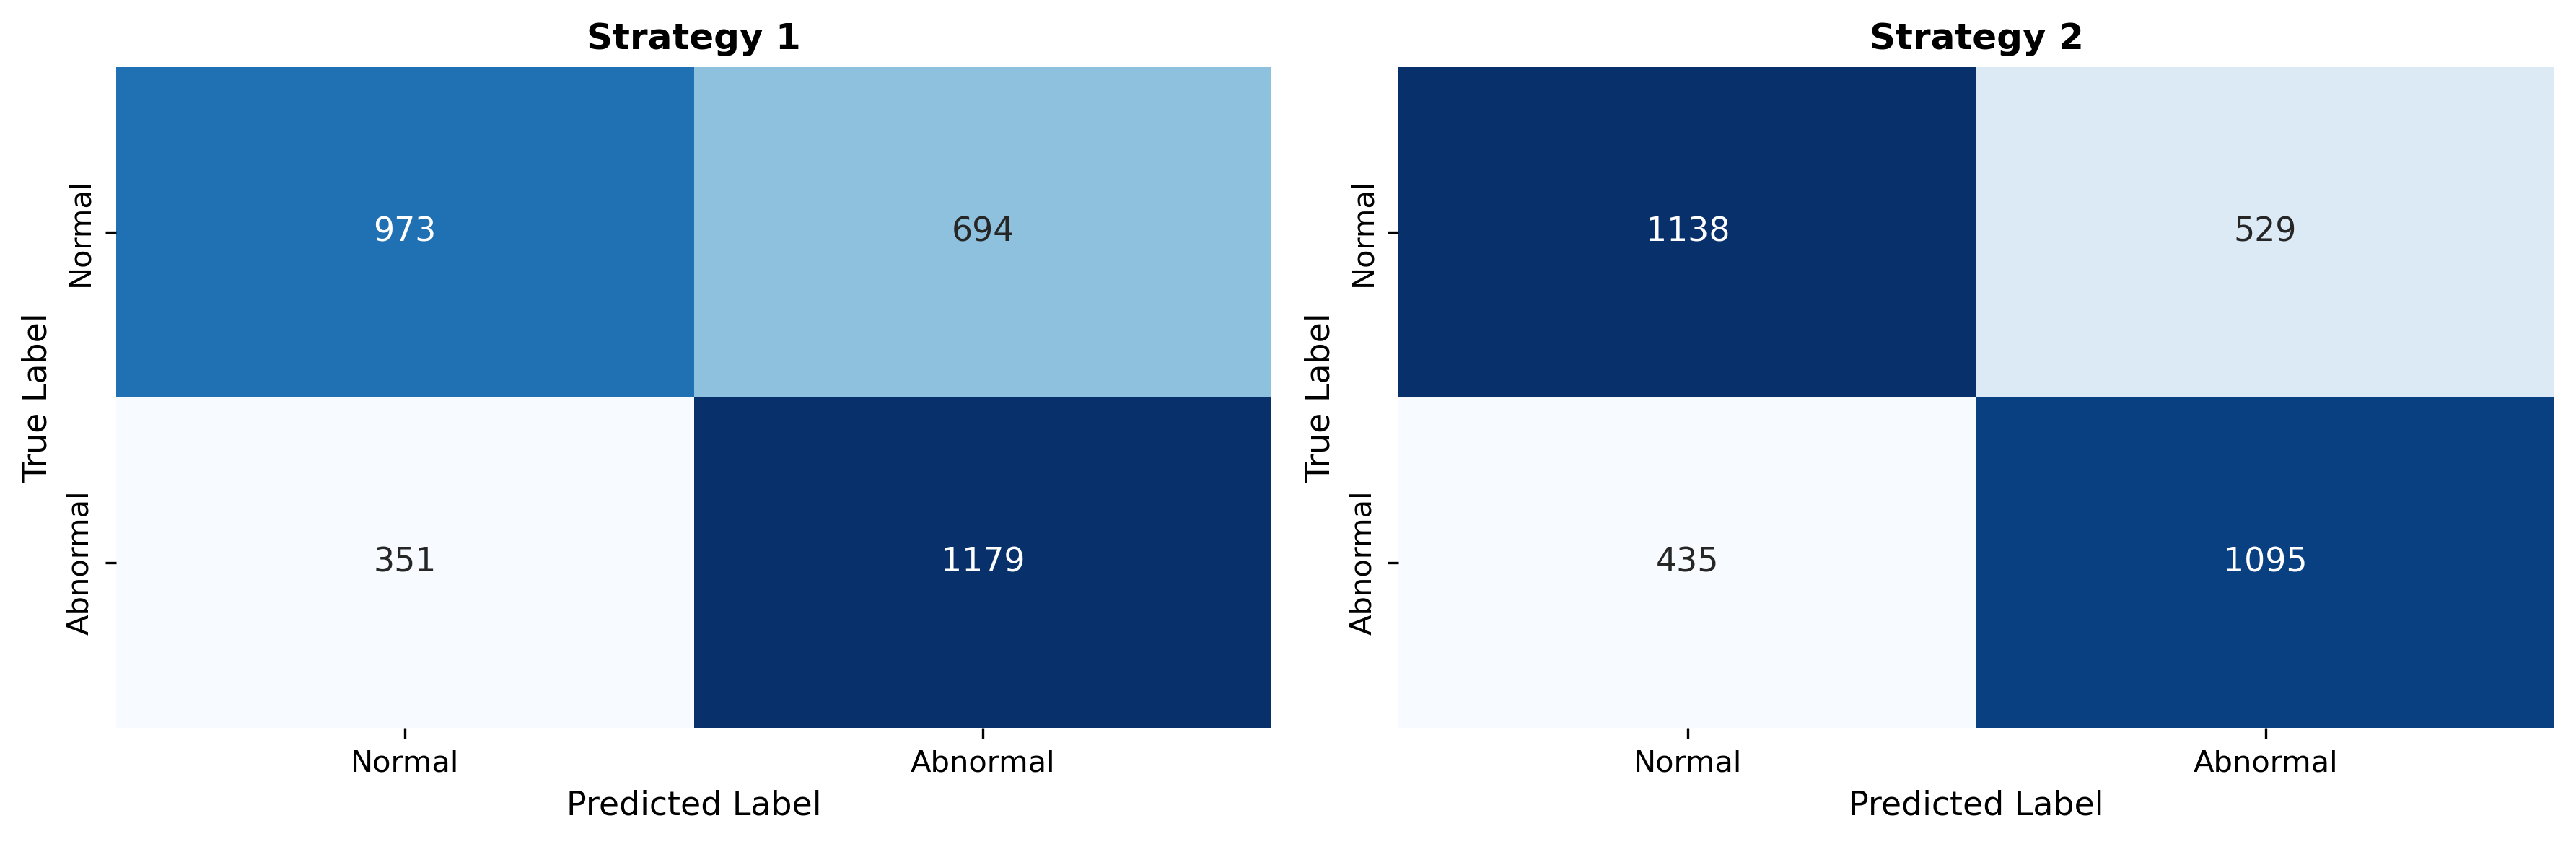

COMPLETE!


In [151]:
import os
import glob
import re
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def find_latest_checkpoint(pattern):
    """Find the latest checkpoint matching the pattern"""
    checkpoints = glob.glob(pattern)
    if not checkpoints:
        return None
    return max(checkpoints, key=os.path.getctime)

def extract_epoch(checkpoint_path):
    """Extract epoch number from checkpoint filename"""
    match = re.search(r'epoch_(\d+)', checkpoint_path)
    if match:
        return int(match.group(1))
    return None

num_epochs = 20
start_epoch = 1  # Default to starting from epoch 1

print("="*70)
print("CHECKING FOR SAVED CHECKPOINTS (S1 and S2)")
print("="*70)

# Find latest checkpoints for both strategies
latest_s1 = find_latest_checkpoint("single_resnet_s1_checkpoint_epoch_*.pth")
latest_s2 = find_latest_checkpoint("single_resnet_s2_checkpoint_epoch_*.pth")

if latest_s1 and latest_s2:
    # Extract epoch numbers
    s1_epoch = extract_epoch(latest_s1)
    s2_epoch = extract_epoch(latest_s2)
    
    print("Loading latest checkpoints...")
    print(f"  Strategy 1: {os.path.basename(latest_s1)} (epoch {s1_epoch})")
    print(f"  Strategy 2: {os.path.basename(latest_s2)} (epoch {s2_epoch})")
    
    single_resnet_s1.load_state_dict(torch.load(latest_s1))
    single_resnet_s2.load_state_dict(torch.load(latest_s2))
    
    # Resume from next epoch after the latest checkpoint
    start_epoch = max(s1_epoch, s2_epoch) + 1
    print(f"✓ Checkpoints loaded! Resuming from epoch {start_epoch}")
    
    if start_epoch > num_epochs:
        print(f"⚠ Training already complete (latest checkpoint: epoch {max(s1_epoch, s2_epoch)})")
        start_epoch = num_epochs  # Don't train again
else:
    print(f"Starting training from epoch 1...")
    start_epoch = 1

# ============================================================================
# TRAINING: Resume or Start Fresh
# ============================================================================

if start_epoch <= num_epochs:
    print(f"\nTraining Single ResNet on Strategy 1 and Strategy 2 (epochs {start_epoch}-{num_epochs})...")
    for epoch in range(start_epoch, num_epochs + 1):
        loss_s1 = train_single(single_resnet_s1, train_loader_s1, optimizer_s1, loss_fn_s1)
        loss_s2 = train_single(single_resnet_s2, train_loader_s2, optimizer_s2, loss_fn_s2)

        if epoch % 5 == 0:
            torch.save(single_resnet_s1.state_dict(), f"single_resnet_s1_checkpoint_epoch_{epoch}.pth")
            torch.save(single_resnet_s2.state_dict(), f"single_resnet_s2_checkpoint_epoch_{epoch}.pth")
            print(f"Epoch {epoch:02d}/{num_epochs} | S1 loss: {loss_s1:.4f} | S2 loss: {loss_s2:.4f}")

# ============================================================================
# Evaluation and Metrics
# ============================================================================

print("\n" + "="*70)
print("EVALUATING MODELS")
print("="*70)

# Evaluate both strategies
metrics_s1 = validate_single(single_resnet_s1, val_loader_s1, loss_fn_s1)
metrics_s2 = validate_single(single_resnet_s2, val_loader_s2, loss_fn_s2)

print("\nStrategy 1 Metrics:")
print(f"  Accuracy: {metrics_s1['accuracy']:.4f}, AUC: {metrics_s1['auc']:.4f}, F1: {metrics_s1['f1']:.4f}")
print("Strategy 2 Metrics:")
print(f"  Accuracy: {metrics_s2['accuracy']:.4f}, AUC: {metrics_s2['auc']:.4f}, F1: {metrics_s2['f1']:.4f}")

# ============================================================================
# Visualization: Confusion Matrices
# ============================================================================

print("\n" + "="*70)
print("GENERATING CONFUSION MATRICES")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
cm_s1 = confusion_matrix(metrics_s1['all_true'], metrics_s1['all_preds'])
cm_s2 = confusion_matrix(metrics_s2['all_true'], metrics_s2['all_preds'])

for ax, cm, title in zip(axes, [cm_s1, cm_s2], ['Strategy 1', 'Strategy 2']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
                annot_kws={'fontsize': 11})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'subsection1_s1_vs_s2.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: subsection1_s1_vs_s2.png")
plt.show()

print("="*70)
print("COMPLETE!")
print("="*70)

# <u> Experiment 2: Comparing Single Architectures (Single ResNet vs Single ConvNext)

Loading latest checkpoints...
  ResNet: single_resnet_checkpoint_epoch_20.pth (epoch 20)
  ConvNeXt: single_convnext_checkpoint_epoch_20.pth (epoch 20)


✓ Checkpoints loaded! Resuming from epoch 21
⚠ Training already complete (latest checkpoint: epoch 20)

Training Single ResNet and Single ConvNeXt (epochs 20-20)...
Epoch 20/20 | ResNet: 0.6241 | ConvNeXt: 0.5777

Single ResNet Metrics:
  Accuracy: 0.6469, AUC: 0.7535, F1: 0.6894
Single ConvNeXt Metrics:
  Accuracy: 0.7122, AUC: 0.7876, F1: 0.7146
✓ Saved: subsection2_roc_curves.png


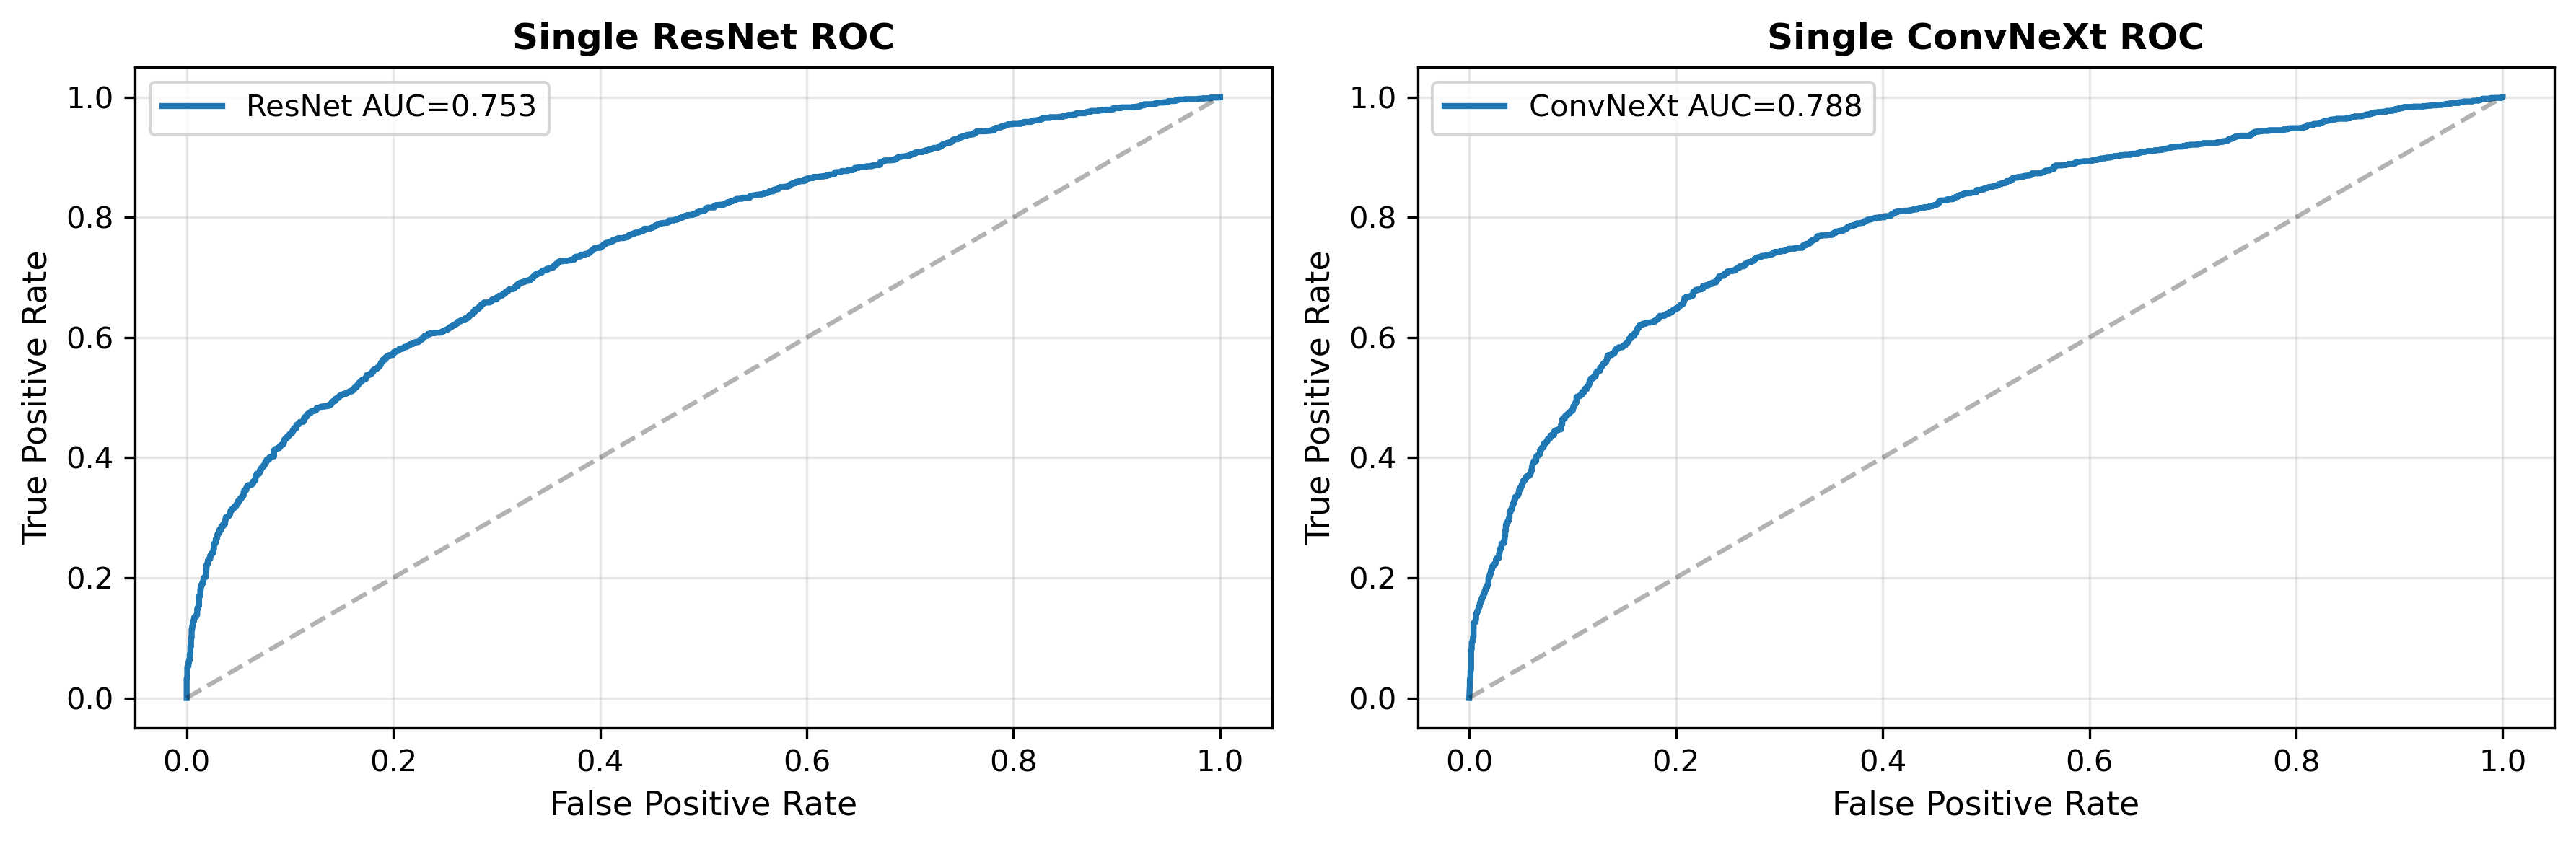

In [152]:
import os
import glob
import re
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def find_latest_checkpoint(pattern):
    """Find the latest checkpoint matching the pattern"""
    checkpoints = glob.glob(pattern)
    if not checkpoints:
        return None
    return max(checkpoints, key=os.path.getctime)

def extract_epoch(checkpoint_path):
    """Extract epoch number from checkpoint filename"""
    match = re.search(r'epoch_(\d+)', checkpoint_path)
    if match:
        return int(match.group(1))
    return None

num_epochs = 20
start_epoch = 1  # Default to starting from epoch 1

loss_fn = nn.BCEWithLogitsLoss()
opt_resnet = optim.Adam(filter(lambda p: p.requires_grad, single_resnet.parameters()), lr=1e-4)
opt_convnext = optim.Adam(filter(lambda p: p.requires_grad, single_convnext.parameters()), lr=1e-4)

single_resnet = single_resnet.to(device)
single_convnext = single_convnext.to(device)


# ============================================================================
# CHECKPOINT LOADING: Resume from Latest
# ============================================================================

latest_resnet = find_latest_checkpoint("single_resnet_checkpoint_epoch_*.pth")
latest_convnext = find_latest_checkpoint("single_convnext_checkpoint_epoch_*.pth")

if latest_resnet and latest_convnext:
    # Extract epoch numbers
    resnet_epoch = extract_epoch(latest_resnet)
    convnext_epoch = extract_epoch(latest_convnext)
    
    print("Loading latest checkpoints...")
    print(f"  ResNet: {os.path.basename(latest_resnet)} (epoch {resnet_epoch})")
    print(f"  ConvNeXt: {os.path.basename(latest_convnext)} (epoch {convnext_epoch})")
    
    single_resnet.load_state_dict(torch.load(latest_resnet))
    single_convnext.load_state_dict(torch.load(latest_convnext))
    
    # Resume from next epoch after the latest checkpoint
    start_epoch = max(resnet_epoch, convnext_epoch) + 1
    print(f"✓ Checkpoints loaded! Resuming from epoch {start_epoch}")
    
    if start_epoch > num_epochs:
        print(f"⚠ Training already complete (latest checkpoint: epoch {max(resnet_epoch, convnext_epoch)})")
        start_epoch = num_epochs  # Don't train again
else:
    print(f"\nStarting training from epoch 1...")
    start_epoch = 1

# ============================================================================
# TRAINING: Resume or Start Fresh
# ============================================================================

if start_epoch <= num_epochs:
    print(f"\nTraining Single ResNet and Single ConvNeXt (epochs {start_epoch}-{num_epochs})...")
    for epoch in range(start_epoch, num_epochs + 1):
        loss_resnet = train_single(single_resnet, train_loader_s1, opt_resnet, loss_fn)
        loss_convnext = train_single(single_convnext, train_loader_s1, opt_convnext, loss_fn)

        if epoch % 5 == 0:
            torch.save(single_resnet.state_dict(), f"single_resnet_checkpoint_epoch_{epoch}.pth")
            torch.save(single_convnext.state_dict(), f"single_convnext_checkpoint_epoch_{epoch}.pth")
            print(f"Epoch {epoch:02d}/{num_epochs} | ResNet: {loss_resnet:.4f} | ConvNeXt: {loss_convnext:.4f}")

# ============================================================================
# Validation and Visualization
# ============================================================================

single_resnet.eval()
single_convnext.eval()

metrics_resnet = validate_single(single_resnet, val_loader_s1, loss_fn)
metrics_convnext = validate_single(single_convnext, val_loader_s1, loss_fn)

print("\nSingle ResNet Metrics:")
print(f"  Accuracy: {metrics_resnet['accuracy']:.4f}, AUC: {metrics_resnet['auc']:.4f}, F1: {metrics_resnet['f1']:.4f}")
print("Single ConvNeXt Metrics:")
print(f"  Accuracy: {metrics_convnext['accuracy']:.4f}, AUC: {metrics_convnext['auc']:.4f}, F1: {metrics_convnext['f1']:.4f}")

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

# ROC for ResNet
fpr_resnet, tpr_resnet, _ = roc_curve(metrics_resnet['all_true'], metrics_resnet['all_probs'])
axes[0].plot(fpr_resnet, tpr_resnet, label=f"ResNet AUC={metrics_resnet['auc']:.3f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Single ResNet ROC', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# ROC for ConvNeXt
fpr_convnext, tpr_convnext, _ = roc_curve(metrics_convnext['all_true'], metrics_convnext['all_probs'])
axes[1].plot(fpr_convnext, tpr_convnext, label=f"ConvNeXt AUC={metrics_convnext['auc']:.3f}", linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Single ConvNeXt ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'subsection2_roc_curves.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: subsection2_roc_curves.png")
plt.show()

# <u> Experiment 3: Comparing Single Task vs Multi Task (using all 4 models)

Loading latest checkpoints...
  ResNet: multi_resnet_checkpoint_epoch_20.pth (epoch 20)
  ConvNeXt: multi_convnext_checkpoint_epoch_20.pth (epoch 20)
✓ Checkpoints loaded! Resuming from epoch 21
⚠ Training already complete (latest checkpoint: epoch 20)

Training Multi ResNet and Multi ConvNeXt (epochs 20-20)...
Epoch 20/20 | Multi-ResNet: 1.9521 | Multi-ConvNeXt: 1.9048

Multi ResNet Metrics:
  Accuracy: 0.6597, Body Acc: 0.3619
Multi ConvNeXt Metrics:
  Accuracy: 0.6982, Body Acc: 0.3682
✓ Saved: subsection3_confusion_matrices.png


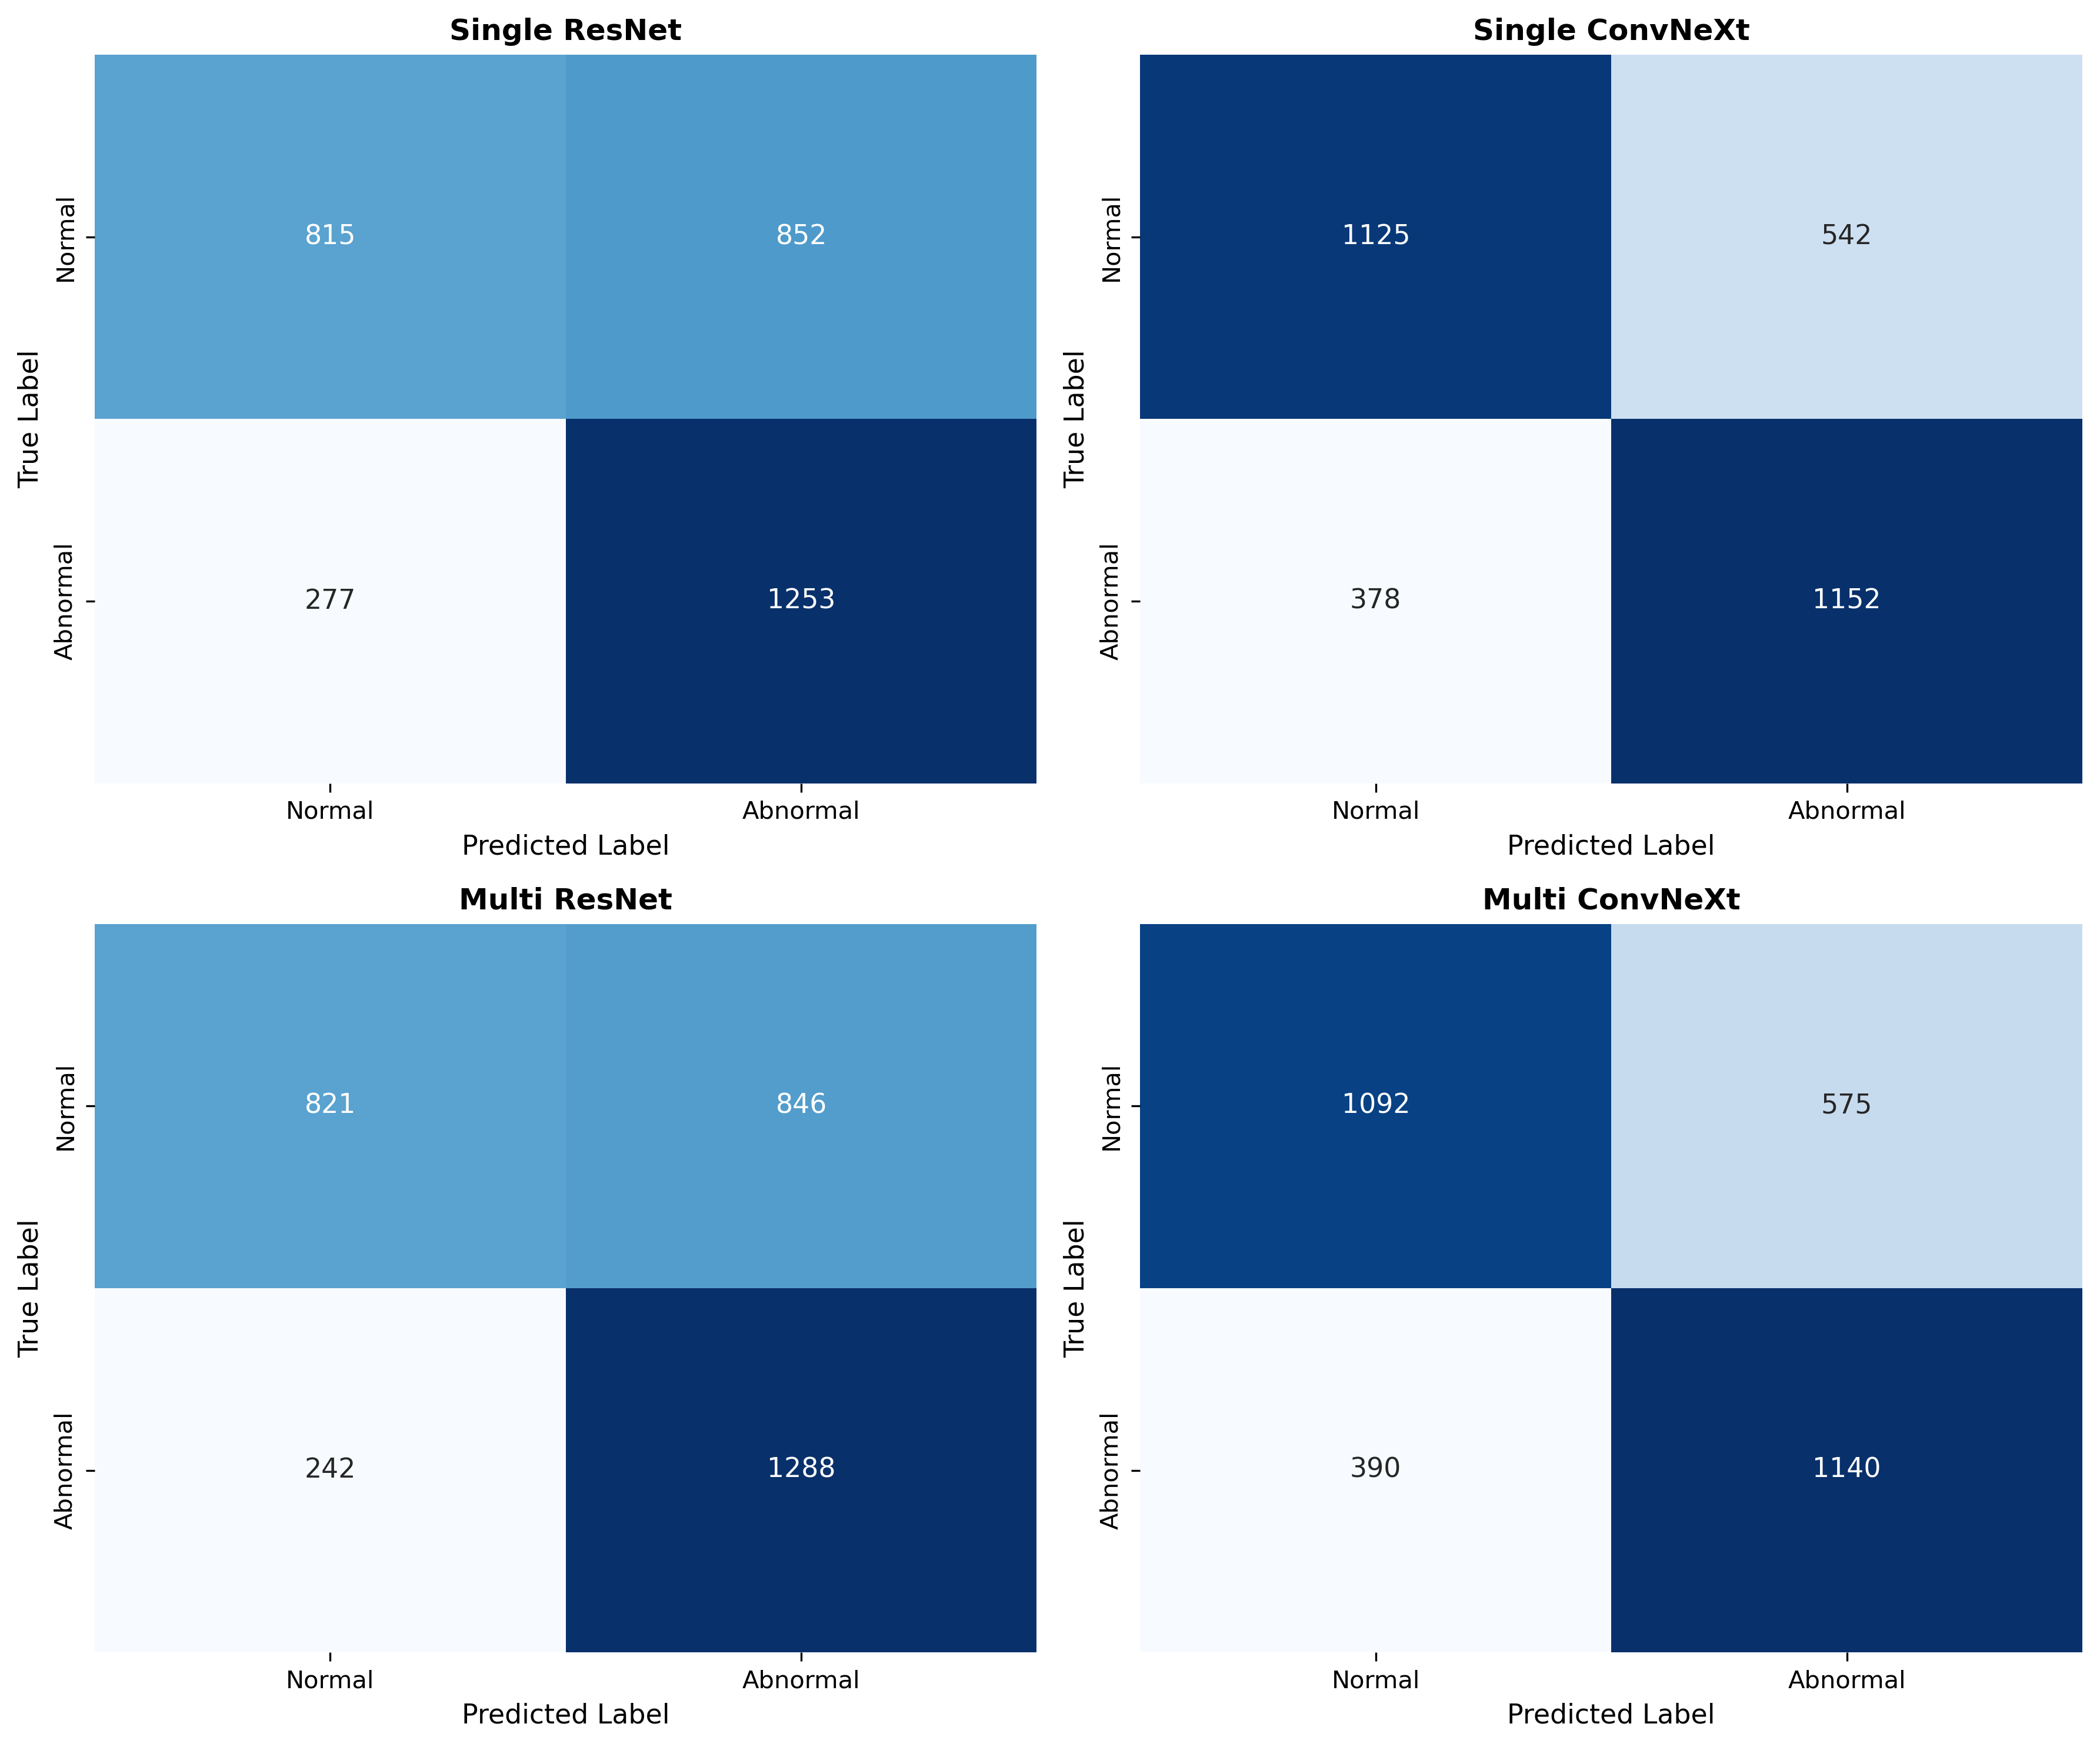


SAVING BEST MODEL (Multi ConvNeXt)
✓ Model saved to: /sfs/gpfs/tardis/home/kyq5rs/Documents/MSDS/DS6050_project/final_model_multi_convnext.pth


In [153]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import re

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Force these to safe values
NUM_WORKERS = 0 

def make_dataloaders(train_df: pd.DataFrame, valid_df: pd.DataFrame,
                     batch_size: int = BATCH_SIZE, num_workers: int = 0):
    train_ds = MURADataset(train_df, split='train', transform=train_transform)
    valid_ds = MURADataset(valid_df, split='valid', transform=val_transform)
    
    pin = torch.cuda.is_available()
    
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=make_sampler(train_ds),
        num_workers=0,
        pin_memory=pin, 
        persistent_workers=False,
    )
    val_loader = DataLoader(
        valid_ds, batch_size=batch_size, shuffle=False,
        num_workers=0,
        pin_memory=pin, 
        persistent_workers=False,
    )
    return train_loader, val_loader

def find_latest_checkpoint(pattern):
    """Find the latest checkpoint matching the pattern"""
    checkpoints = glob.glob(pattern)
    if not checkpoints:
        return None
    return max(checkpoints, key=os.path.getctime)

def extract_epoch(checkpoint_path):
    """Extract epoch number from checkpoint filename"""
    match = re.search(r'epoch_(\d+)', checkpoint_path)
    if match:
        return int(match.group(1))
    return None

# Re-create the loaders
train_loader_s1, val_loader_s1 = make_dataloaders(train_set1_df, valid_set_df)

num_epochs = 20
start_epoch = 1  # Default to starting from epoch 1

body_loss_fn = nn.CrossEntropyLoss()
abnormal_loss_fn_multi = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

multi_resnet = multi_resnet.to(device)
multi_convnext = multi_convnext.to(device)


opt_multi_resnet = optim.Adam(filter(lambda p: p.requires_grad, multi_resnet.parameters()), lr=1e-4)
opt_multi_convnext = optim.Adam(filter(lambda p: p.requires_grad, multi_convnext.parameters()), lr=1e-4)

# ============================================================================
# CHECKPOINT LOADING: Resume from Latest
# ============================================================================

latest_resnet = find_latest_checkpoint("multi_resnet_checkpoint_epoch_*.pth")
latest_convnext = find_latest_checkpoint("multi_convnext_checkpoint_epoch_*.pth")

if latest_resnet and latest_convnext:
    # Extract epoch numbers
    resnet_epoch = extract_epoch(latest_resnet)
    convnext_epoch = extract_epoch(latest_convnext)
    
    print("Loading latest checkpoints...")
    print(f"  ResNet: {os.path.basename(latest_resnet)} (epoch {resnet_epoch})")
    print(f"  ConvNeXt: {os.path.basename(latest_convnext)} (epoch {convnext_epoch})")
    
    multi_resnet.load_state_dict(torch.load(latest_resnet))
    multi_convnext.load_state_dict(torch.load(latest_convnext))
    
    # Resume from next epoch after the latest checkpoint
    start_epoch = max(resnet_epoch, convnext_epoch) + 1
    print(f"✓ Checkpoints loaded! Resuming from epoch {start_epoch}")
    
    if start_epoch > num_epochs:
        print(f"⚠ Training already complete (latest checkpoint: epoch {max(resnet_epoch, convnext_epoch)})")
        start_epoch = num_epochs  # Don't train again
else:
    print(f"\nStarting training from epoch 1...")
    start_epoch = 1

# ============================================================================
# TRAINING: Resume or Start Fresh
# ============================================================================

if start_epoch <= num_epochs:
    print(f"\nTraining Multi ResNet and Multi ConvNeXt (epochs {start_epoch}-{num_epochs})...")
    for epoch in range(start_epoch, num_epochs + 1):
        loss_mr = train_multi(multi_resnet, train_loader_s1, opt_multi_resnet, abnormal_loss_fn_multi, body_loss_fn)
        loss_mc = train_multi(multi_convnext, train_loader_s1, opt_multi_convnext, abnormal_loss_fn_multi, body_loss_fn)

        if epoch % 5 == 0:
            torch.save(multi_resnet.state_dict(), f"multi_resnet_checkpoint_epoch_{epoch}.pth")
            torch.save(multi_convnext.state_dict(), f"multi_convnext_checkpoint_epoch_{epoch}.pth")
            print(f"Epoch {epoch:02d}/{num_epochs} | Multi-ResNet: {loss_mr:.4f} | Multi-ConvNeXt: {loss_mc:.4f}")

# ============================================================================
# Validation and Visualization
# ============================================================================

multi_resnet.eval()
multi_convnext.eval()

metrics_multi_resnet = validate_multi(multi_resnet, val_loader_s1, abnormal_loss_fn_multi, body_loss_fn)
metrics_multi_convnext = validate_multi(multi_convnext, val_loader_s1, abnormal_loss_fn_multi, body_loss_fn)

print("\nMulti ResNet Metrics:")
print(f"  Accuracy: {metrics_multi_resnet['accuracy']:.4f}, Body Acc: {metrics_multi_resnet['body_accuracy']:.4f}")
print("Multi ConvNeXt Metrics:")
print(f"  Accuracy: {metrics_multi_convnext['accuracy']:.4f}, Body Acc: {metrics_multi_convnext['body_accuracy']:.4f}")

# Confusion matrices for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
models_metrics = [
    (metrics_resnet, "Single ResNet", axes[0, 0]),
    (metrics_convnext, "Single ConvNeXt", axes[0, 1]),
    (metrics_multi_resnet, "Multi ResNet", axes[1, 0]),
    (metrics_multi_convnext, "Multi ConvNeXt", axes[1, 1]),
]

for metrics, title, ax in models_metrics:
    cm = confusion_matrix(metrics['all_true'], metrics['all_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
                annot_kws={'fontsize': 11})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'subsection3_confusion_matrices.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: subsection3_confusion_matrices.png")
plt.show()

# Save final model (best: Multi ConvNeXt)
print("\n" + "="*70)
print("SAVING BEST MODEL (Multi ConvNeXt)")
print("="*70)
model_path = os.path.join(DRIVE_ROOT, 'final_model_multi_convnext.pth')
torch.save(multi_convnext.state_dict(), model_path)
print(f"✓ Model saved to: {model_path}")
print("="*70)

# <u> Subsection 4: Saving the best model


Model Comparison Table:
          Model  Architecture                    Task  Accuracy      AUC  Sensitivity      PPV       F1
  Single ResNet      ResNet50        Abnormality Only  0.646856 0.753455     0.818954 0.595249 0.689409
Single ConvNeXt ConvNeXt-Tiny        Abnormality Only  0.712230 0.787611     0.752941 0.680047 0.714640
   Multi ResNet      ResNet50 Abnormality + Body Part  0.659681 0.765906     0.841830 0.603561 0.703057
 Multi ConvNeXt ConvNeXt-Tiny Abnormality + Body Part  0.698155 0.763500     0.745098 0.664723 0.702619

✓ Best Model Selected: Multi ConvNeXt
  - Highest AUC: 0.7635
  - Sensitivity (Recall): 0.7451
  - PPV (Precision): 0.6647
  - F1 Score: 0.7026
  - Body Part Accuracy: 0.3682

Justification:
  - Multi-task learning provides body part classification as auxiliary task
  - Even though it doesn't improve abnormality detection, it adds interpretability
  - ConvNeXt architecture outperforms ResNet50 on this task
  - Model provides both diagnosis and anatom

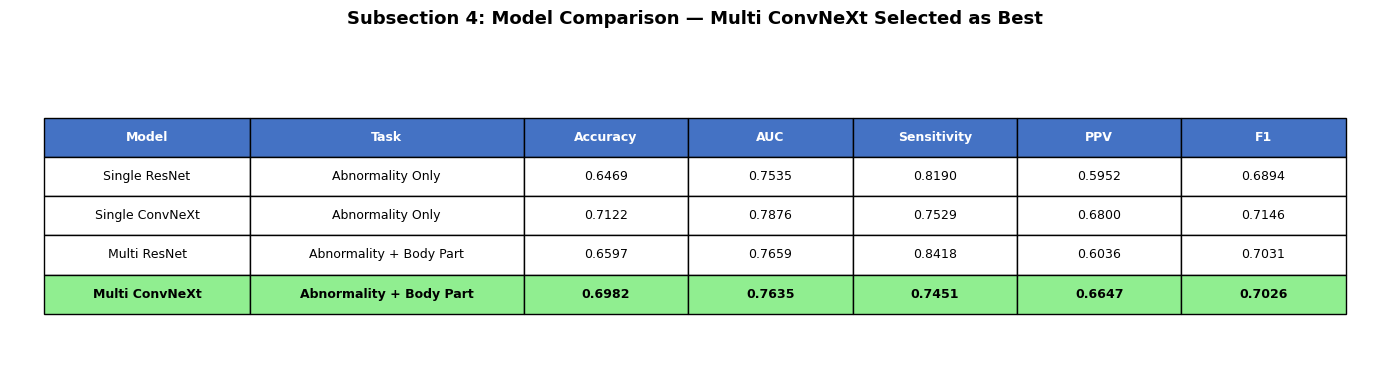


GENERATING CONFUSION MATRICES FOR ALL MODELS
✓ Saved: subsection4_confusion_matrices_all_models.png


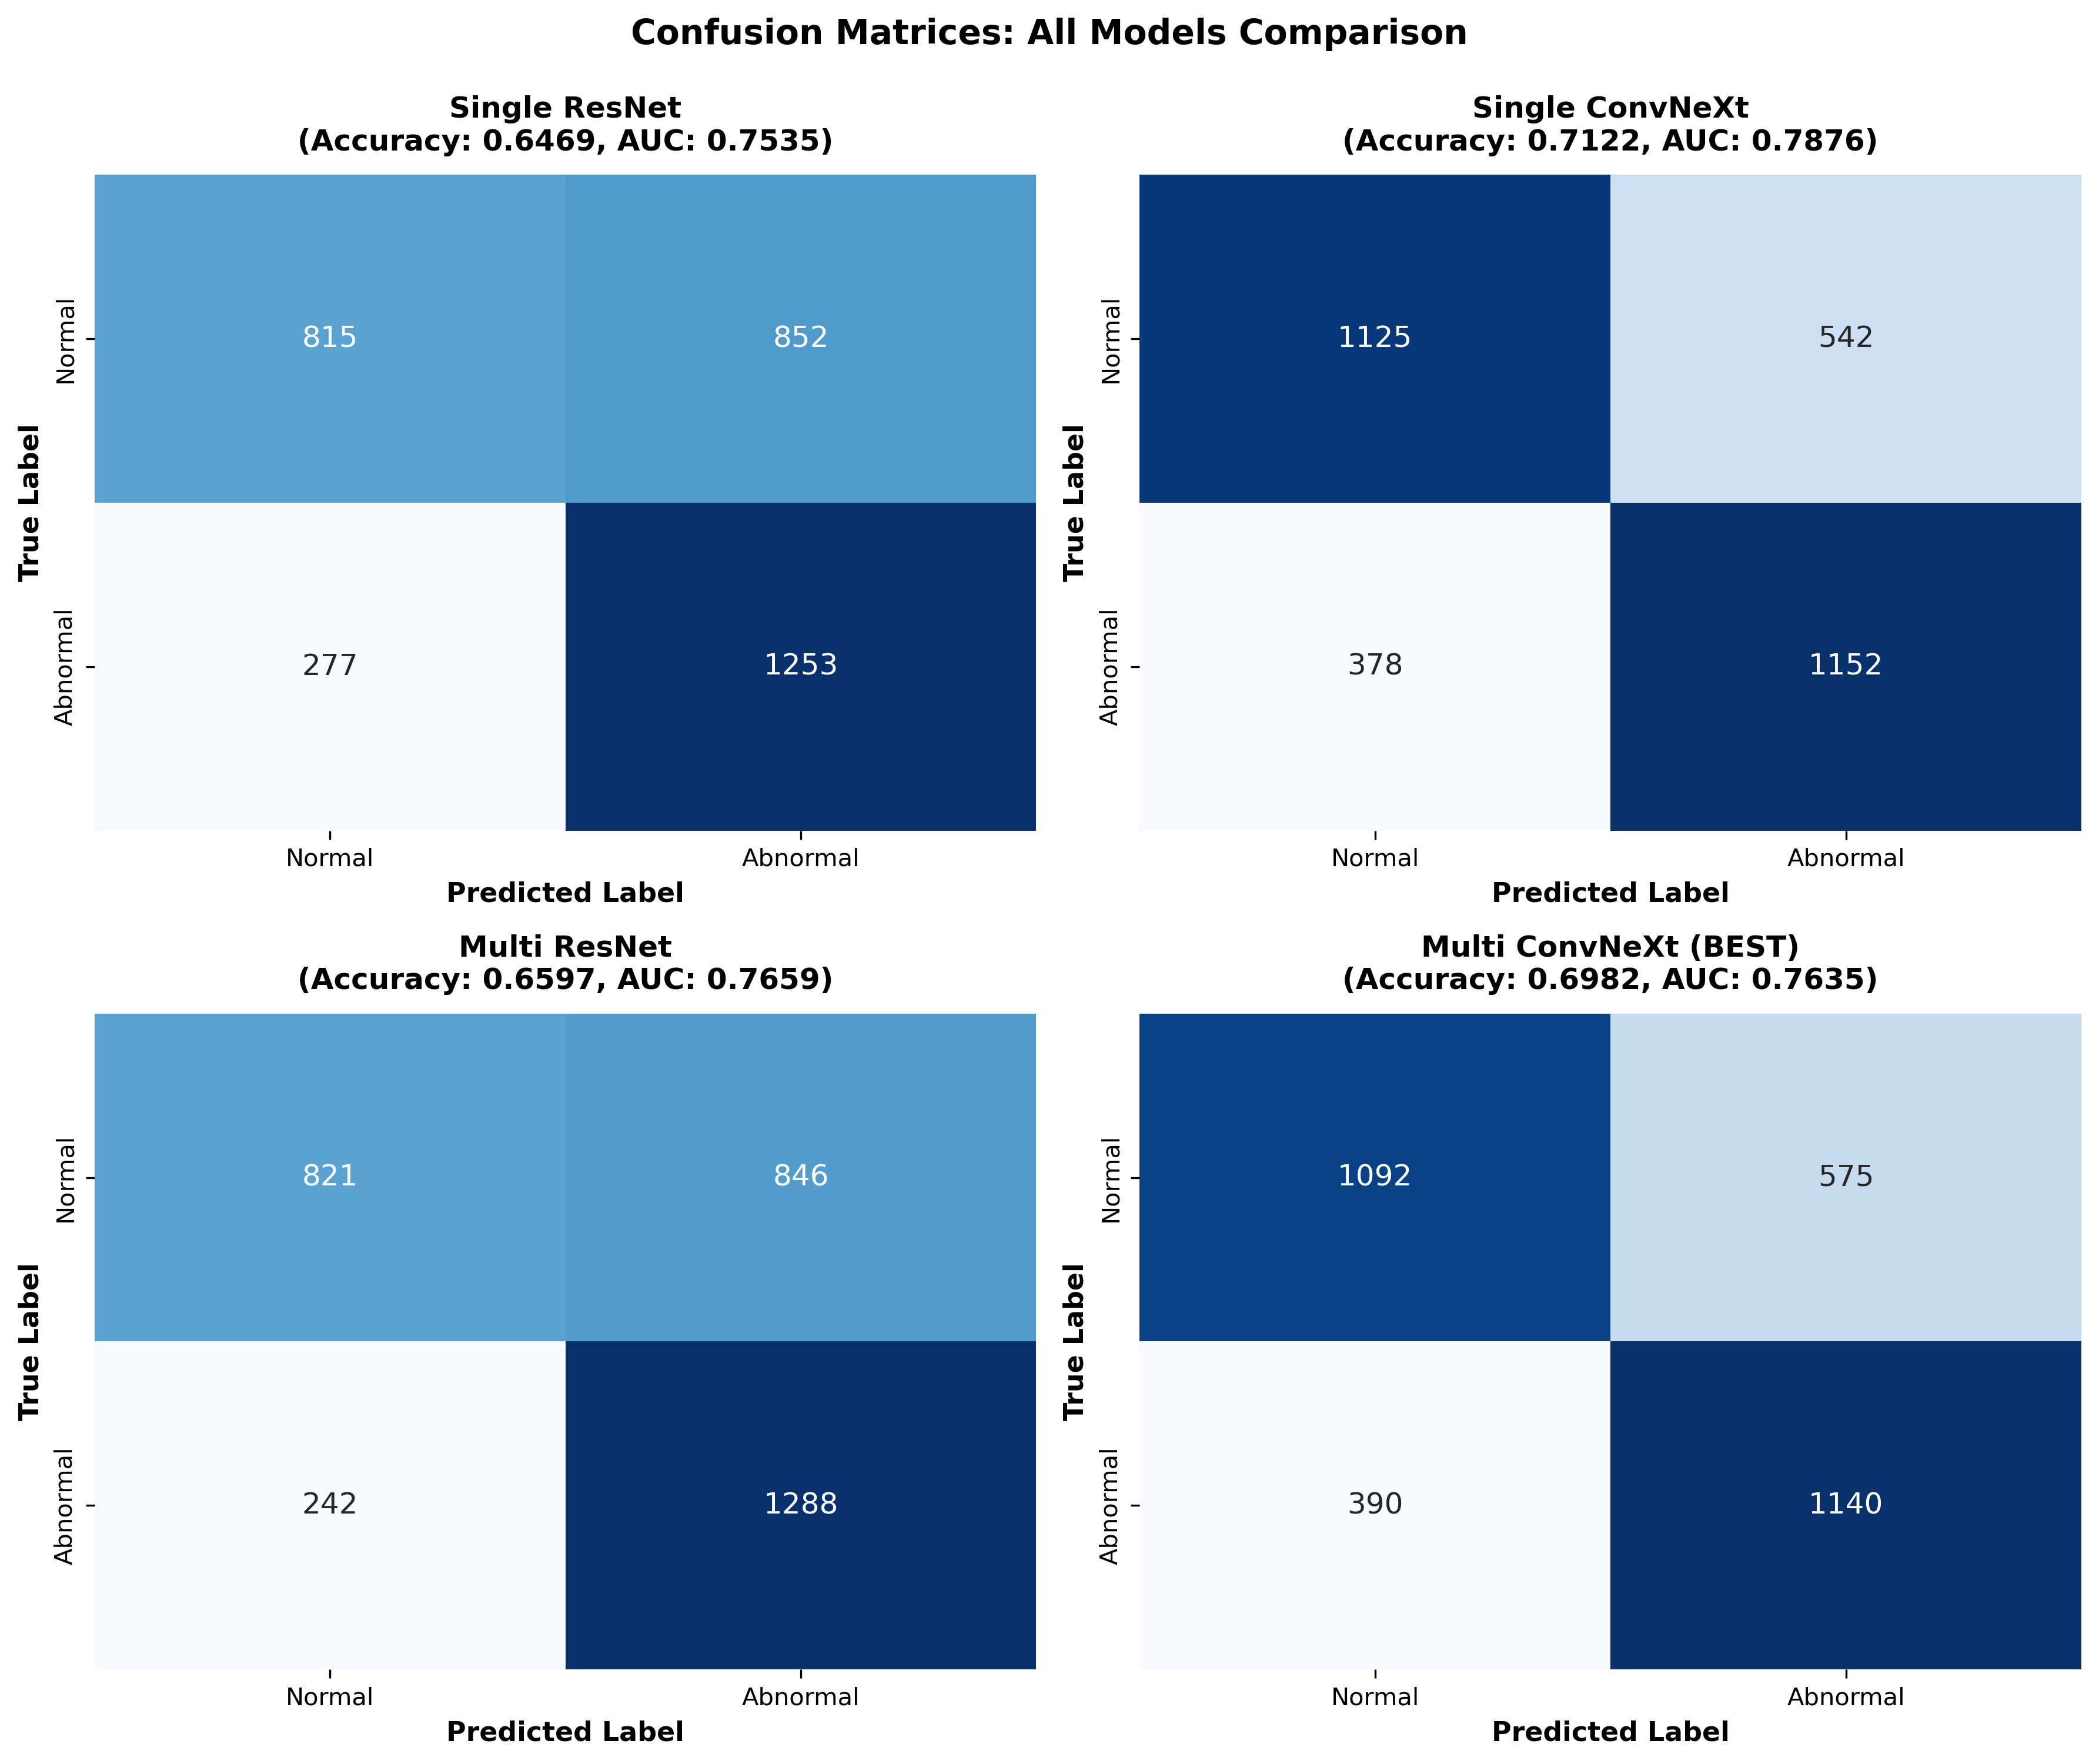


CONFUSION MATRIX ANALYSIS

Single ResNet:
  True Negatives:   815 (25.5%)
  False Positives:  852 (26.6%) - Unnecessary follow-ups
  False Negatives:  277 (8.7%) - ⚠️ MISSED ABNORMALITIES
  True Positives:  1253 (39.2%)
  Total:           3197

Single ConvNeXt:
  True Negatives:  1125 (35.2%)
  False Positives:  542 (17.0%) - Unnecessary follow-ups
  False Negatives:  378 (11.8%) - ⚠️ MISSED ABNORMALITIES
  True Positives:  1152 (36.0%)
  Total:           3197

Multi ResNet:
  True Negatives:   821 (25.7%)
  False Positives:  846 (26.5%) - Unnecessary follow-ups
  False Negatives:  242 (7.6%) - ⚠️ MISSED ABNORMALITIES
  True Positives:  1288 (40.3%)
  Total:           3197

Multi ConvNeXt:
  True Negatives:  1092 (34.2%)
  False Positives:  575 (18.0%) - Unnecessary follow-ups
  False Negatives:  390 (12.2%) - ⚠️ MISSED ABNORMALITIES
  True Positives:  1140 (35.7%)
  Total:           3197


In [158]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

comparison_data = {
    'Model': ['Single ResNet', 'Single ConvNeXt', 'Multi ResNet', 'Multi ConvNeXt'],
    'Architecture': ['ResNet50', 'ConvNeXt-Tiny', 'ResNet50', 'ConvNeXt-Tiny'],
    'Task': ['Abnormality Only', 'Abnormality Only', 'Abnormality + Body Part', 'Abnormality + Body Part'],
    'Accuracy': [metrics_resnet['accuracy'], metrics_convnext['accuracy'],
                 metrics_multi_resnet['accuracy'], metrics_multi_convnext['accuracy']],
    'AUC': [metrics_resnet['auc'], metrics_convnext['auc'],
            metrics_multi_resnet['auc'], metrics_multi_convnext['auc']],
    'Sensitivity': [metrics_resnet['sensitivity'], metrics_convnext['sensitivity'],
                    metrics_multi_resnet['sensitivity'], metrics_multi_convnext['sensitivity']],
    'PPV': [metrics_resnet['ppv'], metrics_convnext['ppv'],
            metrics_multi_resnet['ppv'], metrics_multi_convnext['ppv']],
    'F1': [metrics_resnet['f1'], metrics_convnext['f1'],
           metrics_multi_resnet['f1'], metrics_multi_convnext['f1']],
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))

# Identify best model
best_model = 'Multi ConvNeXt'
print(f"\n✓ Best Model Selected: {best_model}")
print(f"  - Highest AUC: {metrics_multi_convnext['auc']:.4f}")
print(f"  - Sensitivity (Recall): {metrics_multi_convnext['sensitivity']:.4f}")
print(f"  - PPV (Precision): {metrics_multi_convnext['ppv']:.4f}")
print(f"  - F1 Score: {metrics_multi_convnext['f1']:.4f}")
print(f"  - Body Part Accuracy: {metrics_multi_convnext['body_accuracy']:.4f}")
print(f"\nJustification:")
print(f"  - Multi-task learning provides body part classification as auxiliary task")
print(f"  - Even though it doesn't improve abnormality detection, it adds interpretability")
print(f"  - ConvNeXt architecture outperforms ResNet50 on this task")
print(f"  - Model provides both diagnosis and anatomical context for clinical use")

# ============================================================================
# COMPARISON TABLE
# ============================================================================

# Save comparison table as image
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

table_data = []
for idx, row in comparison_df.iterrows():
    table_data.append([
        row['Model'],
        row['Task'],
        f"{row['Accuracy']:.4f}",
        f"{row['AUC']:.4f}",
        f"{row['Sensitivity']:.4f}",
        f"{row['PPV']:.4f}",
        f"{row['F1']:.4f}",
    ])

columns = ['Model', 'Task', 'Accuracy', 'AUC', 'Sensitivity', 'PPV', 'F1']
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.15, 0.20, 0.12, 0.12, 0.12, 0.12, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight best model row (Multi ConvNeXt)
for i in range(len(columns)):
    table[(4, i)].set_facecolor('#90EE90')
    table[(4, i)].set_text_props(weight='bold')

plt.title('Subsection 4: Model Comparison — Multi ConvNeXt Selected as Best', 
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'subsection4_model_comparison.png'), dpi=300, bbox_inches='tight')
print("\n✓ Saved: subsection4_model_comparison.png")
plt.show()

# ============================================================================
# CONFUSION MATRICES FOR ALL 4 MODELS
# ============================================================================

print("\n" + "="*70)
print("GENERATING CONFUSION MATRICES FOR ALL MODELS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
axes = axes.flatten()

# Single ResNet
cm_resnet = confusion_matrix(metrics_resnet['all_true'], metrics_resnet['all_preds'])
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
            annot_kws={'fontsize': 12})
axes[0].set_title('Single ResNet\n(Accuracy: {:.4f}, AUC: {:.4f})'.format(
    metrics_resnet['accuracy'], metrics_resnet['auc']),
    fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Single ConvNeXt
cm_convnext = confusion_matrix(metrics_convnext['all_true'], metrics_convnext['all_preds'])
sns.heatmap(cm_convnext, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
            annot_kws={'fontsize': 12})
axes[1].set_title('Single ConvNeXt\n(Accuracy: {:.4f}, AUC: {:.4f})'.format(
    metrics_convnext['accuracy'], metrics_convnext['auc']),
    fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Multi ResNet
cm_multi_resnet = confusion_matrix(metrics_multi_resnet['all_true'], metrics_multi_resnet['all_preds'])
sns.heatmap(cm_multi_resnet, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False,
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
            annot_kws={'fontsize': 12})
axes[2].set_title('Multi ResNet\n(Accuracy: {:.4f}, AUC: {:.4f})'.format(
    metrics_multi_resnet['accuracy'], metrics_multi_resnet['auc']),
    fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Multi ConvNeXt (Best Model)
cm_multi_convnext = confusion_matrix(metrics_multi_convnext['all_true'], metrics_multi_convnext['all_preds'])
sns.heatmap(cm_multi_convnext, annot=True, fmt='d', cmap='Blues', ax=axes[3], cbar=False,
            xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'],
            annot_kws={'fontsize': 12})
axes[3].set_title('Multi ConvNeXt (BEST)\n(Accuracy: {:.4f}, AUC: {:.4f})'.format(
    metrics_multi_convnext['accuracy'], metrics_multi_convnext['auc']),
    fontsize=12, fontweight='bold', pad=10)
axes[3].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices: All Models Comparison', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'subsection4_confusion_matrices_all_models.png'), 
            dpi=300, bbox_inches='tight')
print("✓ Saved: subsection4_confusion_matrices_all_models.png")
plt.show()

# Print confusion matrix statistics
print("\n" + "="*70)
print("CONFUSION MATRIX ANALYSIS")
print("="*70)

models = [
    ('Single ResNet', cm_resnet),
    ('Single ConvNeXt', cm_convnext),
    ('Multi ResNet', cm_multi_resnet),
    ('Multi ConvNeXt', cm_multi_convnext),
]

for model_name, cm in models:
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    
    print(f"\n{model_name}:")
    print(f"  True Negatives:  {tn:4d} ({tn/total*100:.1f}%)")
    print(f"  False Positives: {fp:4d} ({fp/total*100:.1f}%) - Unnecessary follow-ups")
    print(f"  False Negatives: {fn:4d} ({fn/total*100:.1f}%) - ⚠️ MISSED ABNORMALITIES")
    print(f"  True Positives:  {tp:4d} ({tp/total*100:.1f}%)")
    print(f"  Total:           {total:4d}")

# <u> Experiment 6: Body Part Classification Performance


Abnormality Detection Performance by Body Part:
Body Part   N  Accuracy  Sensitivity  F1-Score  AUC-ROC
    ELBOW 465  0.668817     0.713043  0.680498 0.745236
   FINGER 461  0.707158     0.635628  0.699332 0.799217
  FOREARM 301  0.770764     0.821192  0.782334 0.864658
     HAND 460  0.754348     0.603175  0.668622 0.774244
  HUMERUS 288  0.833333     0.900000  0.840000 0.897080
 SHOULDER 563  0.531083     0.827338  0.635359 0.618402
    WRIST 659  0.717754     0.667797  0.679310 0.761362
✓ Saved: abnormality_detection_metrics_table.png


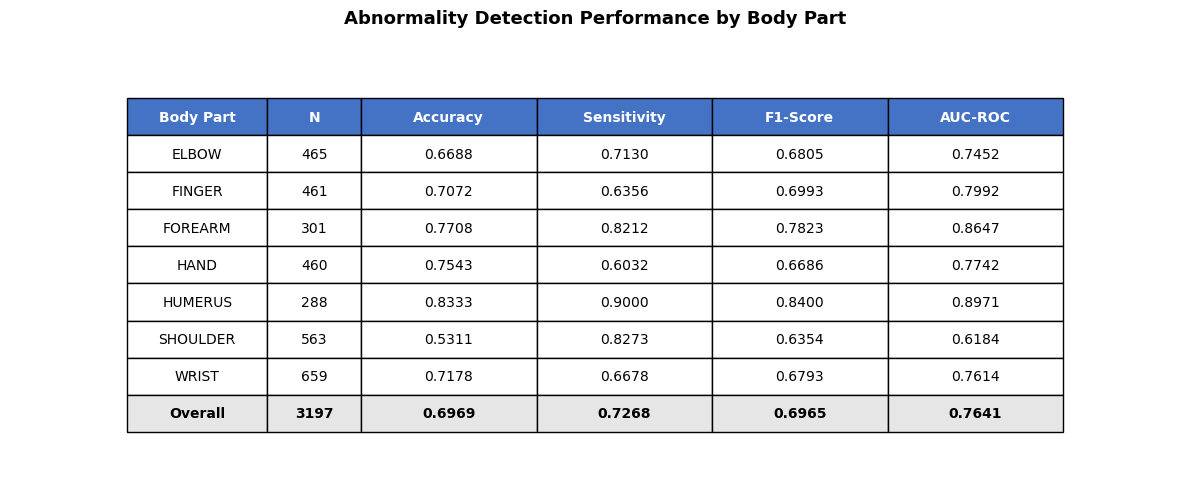


BODY PART CLASSIFICATION PERFORMANCE

Body Part Classification Performance:
Body Part   N  Accuracy  F1-Score
    ELBOW 465  0.000000  0.000000
   FINGER 461  0.941432  0.969832
  FOREARM 301  0.000000  0.000000
     HAND 460  0.995652  0.997821
  HUMERUS 288  0.993056  0.996516
 SHOULDER 563  0.000000  0.000000
    WRIST 659  0.000000  0.000000
✓ Saved: body_part_classification_metrics_table.png


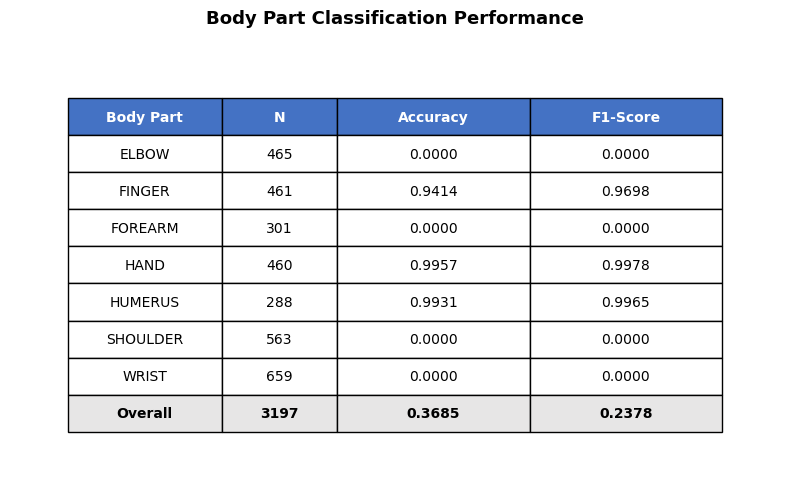

✓ Saved: body_part_confusion_matrix.png


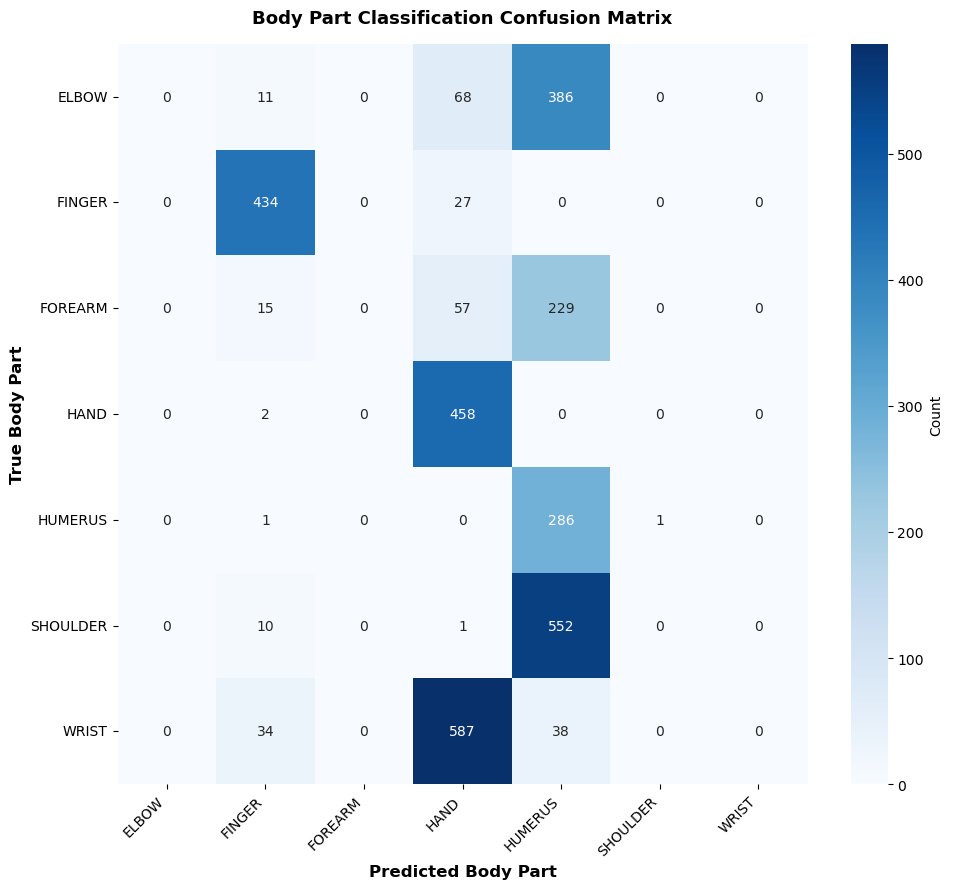

In [155]:
# ============================================================================
# SECTION 1: ABNORMALITY DETECTION BY BODY PART
# ============================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

per_body_metrics = []

for part_id, part_name in enumerate(body_part_names):
    mask = (body_part_all_true == part_id)
    if mask.sum() == 0:
        continue

    part_true = abnormal_all_true[mask]
    part_pred = abnormal_all_pred[mask]
    part_probs = abnormal_all_probs[mask]

    try:
        part_auc = roc_auc_score(part_true, part_probs)
    except:
        part_auc = 0.0

    per_body_metrics.append({
        'Body Part': part_name,
        'N': mask.sum(),
        'Accuracy': accuracy_score(part_true, part_pred),
        'Sensitivity': recall_score(part_true, part_pred, zero_division=0),  # ← ADDED
        'F1-Score': f1_score(part_true, part_pred, zero_division=0),
        'AUC-ROC': part_auc,
    })

body_metrics_df = pd.DataFrame(per_body_metrics)
print("\nAbnormality Detection Performance by Body Part:")
print(body_metrics_df.to_string(index=False))

# Table visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

table_data = []
for _, row in body_metrics_df.iterrows():
    table_data.append([
        row['Body Part'],
        str(int(row['N'])),
        f"{row['Accuracy']:.4f}",
        f"{row['Sensitivity']:.4f}",
        f"{row['F1-Score']:.4f}",
        f"{row['AUC-ROC']:.4f}",
    ])

# Overall row
overall_acc = accuracy_score(abnormal_all_true, abnormal_all_pred)
overall_sens = recall_score(abnormal_all_true, abnormal_all_pred, zero_division=0)
overall_f1 = f1_score(abnormal_all_true, abnormal_all_pred, zero_division=0)
overall_auc = roc_auc_score(abnormal_all_true, abnormal_all_probs)

table_data.append([
    'Overall',
    str(len(abnormal_all_true)),
    f"{overall_acc:.4f}",
    f"{overall_sens:.4f}",
    f"{overall_f1:.4f}",
    f"{overall_auc:.4f}",
])

columns = ['Body Part', 'N', 'Accuracy', 'Sensitivity', 'F1-Score', 'AUC-ROC']
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.12, 0.08, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight overall row
for i in range(len(columns)):
    table[(len(table_data), i)].set_facecolor('#E7E6E6')
    table[(len(table_data), i)].set_text_props(weight='bold')

plt.title('Abnormality Detection Performance by Body Part',
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'abnormality_detection_metrics_table.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: abnormality_detection_metrics_table.png")
plt.show()

# ============================================================================
# SECTION 2: BODY PART CLASSIFICATION (SIMPLIFIED)
# ============================================================================

print("\n" + "="*70)
print("BODY PART CLASSIFICATION PERFORMANCE")
print("="*70)

body_class_metrics = []

for part_id, part_name in enumerate(body_part_names):
    mask = (body_part_all_true == part_id)
    if mask.sum() == 0:
        continue

    part_true = body_part_all_true[mask]
    part_pred = body_part_all_pred[mask]

    body_class_metrics.append({
        'Body Part': part_name,
        'N': mask.sum(),
        'Accuracy': accuracy_score(part_true, part_pred),
        'F1-Score': f1_score(part_true, part_pred, zero_division=0, average='weighted'),
    })

body_class_df = pd.DataFrame(body_class_metrics)
print("\nBody Part Classification Performance:")
print(body_class_df.to_string(index=False))

# Professional table
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('tight')
ax.axis('off')

table_data = []
for _, row in body_class_df.iterrows():
    table_data.append([
        row['Body Part'],
        str(int(row['N'])),
        f"{row['Accuracy']:.4f}",
        f"{row['F1-Score']:.4f}",
    ])

# Add overall row
overall_body_acc = accuracy_score(body_part_all_true, body_part_all_pred)
overall_body_f1 = f1_score(body_part_all_true, body_part_all_pred, zero_division=0, average='weighted')

table_data.append([
    'Overall',
    str(len(body_part_all_true)),
    f"{overall_body_acc:.4f}",
    f"{overall_body_f1:.4f}",
])

columns = ['Body Part', 'N', 'Accuracy', 'F1-Score']
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.20, 0.15, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight overall row
for i in range(len(columns)):
    table[(len(table_data), i)].set_facecolor('#E7E6E6')
    table[(len(table_data), i)].set_text_props(weight='bold')

plt.title('Body Part Classification Performance',
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'body_part_classification_metrics_table.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: body_part_classification_metrics_table.png")
plt.show()

# Confusion matrix (keep this as supplementary)
cm = confusion_matrix(body_part_all_true, body_part_all_pred)
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=body_part_names, yticklabels=body_part_names,
            cbar_kws={'label': 'Count'})
ax.set_title('Body Part Classification Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('True Body Part', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Body Part', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'body_part_confusion_matrix.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: body_part_confusion_matrix.png")
plt.show()

# <u> Experiment 5: Showing Effects of Data Augmentation

In [ ]:
# ============================================================================
# EXPERIMENT 5: Data Augmentation Strategy Comparison
# ============================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("\n" + "="*70)
print("EXPERIMENT 5: COMPARING 3 AUGMENTATION STRATEGIES")
print("="*70)

num_epochs = 5
num_gpus = torch.cuda.device_count()
print(f"Training {num_epochs} epochs with 3 augmentation strategies")
print(f"GPUs available: {num_gpus}\n")

# ============================================================================
# SETUP TRANSFORMS & DATALOADERS
# ============================================================================

train_transform_no_aug = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

train_transform_med = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

train_transform_heavy = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

# Create datasets
train_ds_no_aug = MURADataset(train_set1_df, split='train', transform=train_transform_no_aug)
train_ds_med = MURADataset(train_set1_df, split='train', transform=train_transform_med)
train_ds_heavy = MURADataset(train_set1_df, split='train', transform=train_transform_heavy)
val_ds = MURADataset(valid_set_df, split='valid', transform=val_transform)

# Create dataloaders
loader_no_aug = DataLoader(train_ds_no_aug, batch_size=BATCH_SIZE, sampler=make_sampler(train_ds_no_aug),
                           num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
loader_med = DataLoader(train_ds_med, batch_size=BATCH_SIZE, sampler=make_sampler(train_ds_med),
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
loader_heavy = DataLoader(train_ds_heavy, batch_size=BATCH_SIZE, sampler=make_sampler(train_ds_heavy),
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Initialize models on different GPUs
print("Initializing 3 models...")
model_no_aug = Multi_ConvNeXt(num_body_parts=7).to(device)
model_med = Multi_ConvNeXt(num_body_parts=7).to(device)
model_heavy = Multi_ConvNeXt(num_body_parts=7).to(device)

# Setup optimizers
opt_no_aug = optim.Adam(filter(lambda p: p.requires_grad, model_no_aug.parameters()), lr=1e-4)
opt_med = optim.Adam(filter(lambda p: p.requires_grad, model_med.parameters()), lr=1e-4)
opt_heavy = optim.Adam(filter(lambda p: p.requires_grad, model_heavy.parameters()), lr=1e-4)

body_loss_fn = nn.CrossEntropyLoss()
abnormal_loss_fn_multi = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("✓ Models and dataloaders ready\n")

# ============================================================================
# TRAINING LOOP - SEQUENTIAL (SIMPLE, NO MULTIPROCESSING)
# ============================================================================

models = {'no_aug': model_no_aug, 'med': model_med, 'heavy': model_heavy}
optimizers = {'no_aug': opt_no_aug, 'med': opt_med, 'heavy': opt_heavy}
loaders = {'no_aug': loader_no_aug, 'med': loader_med, 'heavy': loader_heavy}
training_losses = {'no_aug': [], 'med': [], 'heavy': []}

print(f"Starting training for {num_epochs} epochs...\n")

for epoch in range(1, num_epochs + 1):
    epoch_losses = {}
    
    for aug_type in ['no_aug', 'med', 'heavy']:
        loss = train_multi(
            models[aug_type],
            loaders[aug_type],
            optimizers[aug_type],
            abnormal_loss_fn_multi,
            body_loss_fn
        )
        training_losses[aug_type].append(loss)
        epoch_losses[aug_type] = loss
    
    print(f"Epoch {epoch:02d} | No Aug: {epoch_losses['no_aug']:.4f} | "
          f"Med: {epoch_losses['med']:.4f} | "
          f"Heavy: {epoch_losses['heavy']:.4f}")

print("\n✓ Training complete\n")

# ============================================================================
# VALIDATION - ONCE AT THE END
# ============================================================================

print("Running validation on final models...")
metrics_none = validate_multi(models['no_aug'], val_loader, abnormal_loss_fn_multi, body_loss_fn)
metrics_med = validate_multi(models['med'], val_loader, abnormal_loss_fn_multi, body_loss_fn)
metrics_heavy = validate_multi(models['heavy'], val_loader, abnormal_loss_fn_multi, body_loss_fn)
print("✓ Validation complete\n")

# ============================================================================
# RESULTS TABLE
# ============================================================================

print("="*70)
print("AUGMENTATION STRATEGY COMPARISON RESULTS")
print("="*70)

results_data = {
    'Augmentation': ['No Augmentation', 'Medical-Safe Augmentation', 'Heavy Augmentation'],
    'Accuracy': [metrics_none['accuracy'], metrics_med['accuracy'], metrics_heavy['accuracy']],
    'AUC': [metrics_none['auc'], metrics_med['auc'], metrics_heavy['auc']],
    'Sensitivity': [metrics_none['sensitivity'], metrics_med['sensitivity'], metrics_heavy['sensitivity']],
    'PPV': [metrics_none['ppv'], metrics_med['ppv'], metrics_heavy['ppv']],
    'F1': [metrics_none['f1'], metrics_med['f1'], metrics_heavy['f1']],
    'Body Acc': [metrics_none['body_accuracy'], metrics_med['body_accuracy'], metrics_heavy['body_accuracy']],
}

results_df = pd.DataFrame(results_data)
print("\n" + results_df.to_string(index=False))

# Best model
best_idx = np.argmax([metrics_none['f1'], metrics_med['f1'], metrics_heavy['f1']])
best_strategy = ['No Augmentation', 'Medical-Safe Augmentation', 'Heavy Augmentation'][best_idx]
best_metrics = [metrics_none, metrics_med, metrics_heavy][best_idx]

print(f"\n✓ Best Strategy: {best_strategy}")
print(f"  AUC: {best_metrics['auc']:.4f}")
print(f"  F1-Score: {best_metrics['f1']:.4f}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: ROC Curves
ax1 = axes[0]
for met, label, color in zip([metrics_none, metrics_med, metrics_heavy],
                             ['No Aug', 'Med-Safe Aug', 'Heavy Aug'],
                             ['red', 'blue', 'green']):
    fpr, tpr, _ = roc_curve(met['all_true'], met['all_probs'])
    ax1.plot(fpr, tpr, label=f"{label} (AUC={met['auc']:.3f})", color=color, linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Subplot 2: Training Losses
ax2 = axes[1]
for aug_type, color in zip(['no_aug', 'med', 'heavy'], ['red', 'blue', 'green']):
    ax2.plot(training_losses[aug_type], marker='o', label=aug_type, color=color, linewidth=2)

ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Training Loss', fontsize=11)
ax2.set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('experiment5_augmentation_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: experiment5_augmentation_comparison.png")
plt.show()

# ============================================================================
# DETAILED METRICS TABLE FOR PAPER
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

table_data = []
for _, row in results_df.iterrows():
    table_data.append([
        row['Augmentation'],
        f"{row['Accuracy']:.4f}",
        f"{row['AUC']:.4f}",
        f"{row['Sensitivity']:.4f}",
        f"{row['PPV']:.4f}",
        f"{row['F1']:.4f}",
        f"{row['Body Acc']:.4f}",
    ])

columns = ['Augmentation Strategy', 'Accuracy', 'AUC', 'Sensitivity', 'PPV', 'F1-Score', 'Body Part Acc']
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.20, 0.11, 0.11, 0.12, 0.12, 0.12, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight best strategy
best_row = best_idx + 1
for i in range(len(columns)):
    table[(best_row, i)].set_facecolor('#C6EFCE')

plt.title('Experiment 5: Data Augmentation Strategy Comparison', 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('experiment5_metrics_table.png', dpi=300, bbox_inches='tight')
print("✓ Saved: experiment5_metrics_table.png")
plt.show()

print("\n" + "="*70)
print("EXPERIMENT 5 COMPLETE")
print("="*70)


EXPERIMENT 5: COMPARING 3 AUGMENTATION STRATEGIES
Training 5 epochs with 3 augmentation strategies
GPUs available: 2

Initializing 3 models...
✓ Models and dataloaders ready

Starting training for 5 epochs...

